# Visium-HD Pre-process v3
https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-human-lung-cancer-if

In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

env: ANYWIDGET_HMR=1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import celldega as dega
from ipywidgets import Widget
from pathlib import Path
import os
import json
import h5py
import matplotlib.pyplot as plt
from PIL import Image
from copy import deepcopy

/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


# Pre-process LandscapeFiles

In [3]:
# dataset = 'Visium_HD_Mouse_Lung_Fresh_Frozen_binned_outputs'

dataset = 'Visium_HD_Human_Lung_Cancer_binned_outputs'
base_path = 'data/visium-hd_data/' + dataset + '/binned_outputs/square_008um/'
landscape_files_path = 'data/landscape_files/' + dataset + '_2025-08-04'

# Tile Positions

In [4]:
df_pos = pd.read_parquet(base_path + 'spatial/tissue_positions.parquet')
df_pos = df_pos[df_pos['in_tissue'] == 1]
print (df_pos.shape)
print (f'Total number of spots: {df_pos.shape[0]/1e6} M')
df_pos.head()

(605471, 6)
Total number of spots: 0.605471 M


,barcode,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
60,s_008um_00000_00060-1,1,0,60,4455.255106,19771.540493
61,s_008um_00000_00061-1,1,0,61,4455.410118,19746.924147
62,s_008um_00000_00062-1,1,0,62,4455.565131,19722.307801
63,s_008um_00000_00063-1,1,0,63,4455.720143,19697.691455
64,s_008um_00000_00064-1,1,0,64,4455.875156,19673.075109


In [5]:
ls data/visium-hd_data/Visium_HD_Human_Lung_Cancer_binned_outputs/

binned_outputs/


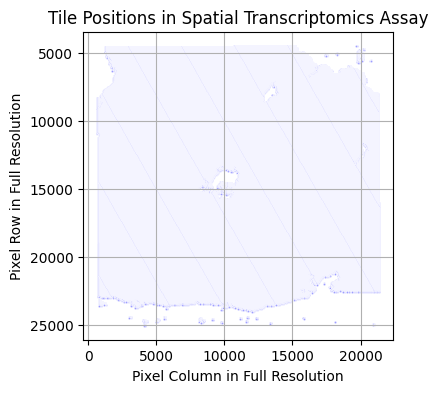

In [6]:
# Plotting
plt.figure(figsize=(4, 4))
plt.scatter(df_pos['pxl_col_in_fullres'], df_pos['pxl_row_in_fullres'], c='blue', alpha=0.6, edgecolors='w', s=2)
plt.title('Tile Positions in Spatial Transcriptomics Assay')
plt.xlabel('Pixel Column in Full Resolution')
plt.ylabel('Pixel Row in Full Resolution')
plt.gca().invert_yaxis()  # Invert y-axis to match the image coordinates
plt.grid(True)
plt.show()

In [7]:
filepath_scalefactors = base_path + 'spatial/scalefactors_json.json'
with open(filepath_scalefactors) as file:
    data = json.load(file)
scale_factor = data['tissue_hires_scalef']

data

{'spot_diameter_fullres': 24.616732333013957,
 'bin_size_um': 8.0,
 'microns_per_pixel': 0.3249822068898662,
 'regist_target_img_scalef': 0.24899365,
 'tissue_lowres_scalef': 0.024899365,
 'fiducial_diameter_fullres': 1015.4402087368256,
 'tissue_hires_scalef': 0.24899365}

In [8]:
df_pos['x_scaled'] = df_pos['pxl_col_in_fullres'] * scale_factor
df_pos['y_scaled'] = df_pos['pxl_row_in_fullres'] * scale_factor

print(df_pos.x_scaled.min(), df_pos.x_scaled.max())
print(df_pos.y_scaled.min(), df_pos.y_scaled.max())

print (df_pos.shape)

166.29113698017858 5319.122746611531
1109.330230448846 6239.840157345033
(605471, 8)


In [9]:
# Sample 10% of the rows randomly
df_sample = df_pos.sample(frac=0.01)
df_sample.shape

(6055, 8)

In [ ]:
img = Image.open(f'{base_path}/spatial/tissue_hires_image.png')
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img)
ax.scatter(df_sample['x_scaled'], df_sample['y_scaled'], color='red', s=0.1, alpha=1)
plt.show()

In [ ]:
meta_tile = pd.read_csv(base_path + 'analysis/clustering/gene_expression_graphclust/clusters.csv')
meta_tile.head(5)

In [ ]:
from matplotlib.colors import to_hex
# Get all categorical color palettes from Matplotlib and flatten them into a single list of colors
palettes = [plt.get_cmap(name).colors for name in plt.colormaps() if "tab" in name]
flat_colors = [color for palette in palettes for color in palette]

# Convert RGB tuples to hex codes
flat_colors_hex = [to_hex(color) for color in flat_colors]

In [ ]:
meta_tile['Cluster'].value_counts()

In [ ]:
if not os.path.exists(landscape_files_path):
    os.mkdir(landscape_files_path)

In [ ]:
clusters = [str(x) for x in meta_tile['Cluster'].unique().tolist()]

# Use modular arithmetic to assign a color to each gene, white for genes with "Blank"
colors = [flat_colors_hex[i % len(flat_colors_hex)] if "Blank" not in cluster else "#FFFFFF" for i, cluster in enumerate(clusters)]

# Create a DataFrame with genes and their assigned colors
df_colors = pd.DataFrame({'color': colors}, index=clusters)
df_colors.to_parquet(f"{landscape_files_path}/df_colors.parquet")
df_colors.head()

In [ ]:
# meta_tile_json = meta_tile.to_json(orient='records')
meta_tile_json = dict(zip(meta_tile['Barcode'], meta_tile['Cluster']))
json_output = json.dumps(meta_tile_json)

with open(f"{landscape_files_path}/meta_tile.json", 'w') as file:
    file.write(json_output)

meta_tile.head()

In [ ]:
tile = pd.DataFrame()
tile['name'] = df_pos['barcode']

# tile['center_x'] = df_pos['pxl_col_in_fullres'].round(1)
# tile['center_y'] = df_pos['pxl_row_in_fullres'].round(1)

tile['center_x'] = df_pos['x_scaled'] # .round(1)
tile['center_y'] = df_pos['y_scaled'] # .round(1)

tile['center_x'] = tile['center_x'].astype(float)
tile['center_y'] = tile['center_y'].astype(float)

In [ ]:

path_tile_geo = f"{landscape_files_path}/tile_geometries.parquet"
# pd.read_parquet(path_tile_geo).head()

In [ ]:
tile_merge = deepcopy(tile)
tile_merge.index = tile['name'].values.tolist()
display(tile_merge.head())

meta_tile_merge = deepcopy(meta_tile)
meta_tile_merge.index = meta_tile['Barcode'].values.tolist()
display(meta_tile_merge.head())

In [ ]:
cats = [str(x) for x in meta_tile_merge['Cluster'].values.tolist()]
keep_tiles = meta_tile_merge.index.tolist()
tile_merge.loc[keep_tiles, 'cluster'] = pd.Series(cats, index=keep_tiles)
tile_merge.to_parquet(f'{landscape_files_path}/meta_tile.parquet')
display(tile_merge.head())
print (tile_merge.center_x.mean(), tile_merge.center_y.mean())

In [ ]:
tile_merge['geometry'] = tile_merge.apply(lambda row: [row['center_x'], row['center_y']], axis=1)
tile_merge.loc[keep_tiles, ['name', 'geometry', 'cluster']].to_parquet(path_tile_geo)
display(tile_merge.head())

In [ ]:
file_path = base_path + 'filtered_feature_bc_matrix.h5'

In [ ]:
# def print_structure(file, indent = ' '):
#     """Recursively prints the groups and datasets in an HDF5 file."""
#     for key in file.keys():
#         item = file[key]
#         print(indent, key)
#         if isinstance(item, h5py.Dataset):
#             print(indent + ' ', "Dataset")
#         elif isinstance(item, h5py.Group):
#             print_structure(item, indent + ' ')

# with h5py.File(file_path, 'r') as file:
#     print_structure(file)


# Read Tile-by-Gene Sparse Matrix

In [ ]:
import pandas as pd
from scipy.io import mmread
from scipy.sparse import csr_matrix

In [ ]:
def make_unique(names):
    from collections import Counter
    counts = Counter(names)
    new_names = []
    used_names = {}

    for name in names:
        if counts[name] > 1:  # If this name is a duplicate
            if name in used_names:
                used_names[name] += 1
            else:
                used_names[name] = 1
            new_name = f"{name}-{used_names[name]}"
        else:
            new_name = name
        new_names.append(new_name)

    return new_names

In [ ]:
%%time
# File paths
barcodes_path = base_path + 'filtered_feature_bc_matrix/barcodes.tsv.gz'
features_path = base_path + 'filtered_feature_bc_matrix/features.tsv.gz'
matrix_path = base_path + 'filtered_feature_bc_matrix/matrix.mtx.gz'

# Read barcodes and features
barcodes = pd.read_csv(barcodes_path, header=None, compression='gzip')
features = pd.read_csv(features_path, header=None, compression='gzip', sep='\t')

# Read the gene expression matrix and transpose it
matrix = mmread(matrix_path).transpose().tocsc()  # Transpose and convert to CSC

# Create a sparse DataFrame with genes as columns and barcodes as rows
tbg = pd.DataFrame.sparse.from_spmatrix(matrix, index=barcodes[0], columns=features[1])
tbg.columns = make_unique(tbg.columns.tolist())

print(tbg.shape)
tbg.columns.tolist()[:10]

In [ ]:
meta_tile = pd.read_parquet(f'{landscape_files_path}/meta_tile.parquet')
meta_tile.head()

In [ ]:
tbg.head()

In [ ]:
gene_exp = tbg.sum()

In [ ]:
%%time
# Calculate mean expression across tiles with float precision
print('calculating mean expression from sparse float data')
mean_expression = tbg.astype(pd.SparseDtype("float", 0)).mean(axis=0)

# Calculate the variance as the average of the squared deviations
print('calculating variance by looping over rows')
num_tiles = tbg.shape[1]
variance = tbg.apply(lambda x: ((x - mean_expression[x.name]) ** 2).sum() / num_tiles, axis=0)
std_deviation = np.sqrt(variance)

# # Assuming mean_expression is aligned with columns
# print('calculating variance using vectorized approach')
# squared_deviations = (tbg - mean_expression) ** 2
# variance = squared_deviations.mean(axis=0)

# Calculate maximum expression
max_expression = tbg.max(axis=0)

# Calculate proportion of tiles with non-zero expression
proportion_nonzero = (tbg != 0).sum(axis=0) / len(tbg)

# Create a DataFrame to hold all these metrics
meta_gene = pd.DataFrame({
    'mean': mean_expression,
    'std': std_deviation,
    'max': max_expression,
    'non-zero': proportion_nonzero
})

In [ ]:
meta_gene.head()

In [ ]:
meta_gene['max'].sort_values(ascending=False).head(10)

In [ ]:
# Convert only the sparse columns to dense
for column in meta_gene.columns:
    # Check if the column dtype is an instance of pd.SparseDtype
    if isinstance(meta_gene[column].dtype, pd.SparseDtype):
        meta_gene[column] = meta_gene[column].sparse.to_dense()

In [ ]:
meta_gene.to_parquet(f'{landscape_files_path}/meta_gene.parquet')

In [ ]:
%%time
mean_expression = tbg.astype(pd.SparseDtype("float", 0)).mean(axis=0)
mean_expression

In [ ]:
mean_expression.sort_values(ascending=False).head(5)

# save tile-by-gene parquet files

In [ ]:
# need to run this just commenting out to prevent re-running
################################################################
output_dir = f'{landscape_files_path}/tbg/'
os.makedirs(output_dir, exist_ok=True)

for index, gene in enumerate(tbg.columns):
    if index % 500 == 0:
        print(index)
    # Extract the column as a DataFrame
    col_df = tbg[[gene]].copy()

    col_df = col_df.sparse.to_dense()
    # col_df.fillna(0, inplace=True)
    col_df = col_df.astype(int)

    inst_df = pd.DataFrame(col_df.values, columns=[gene], index=col_df.index.tolist())

    inst_df = inst_df.loc[keep_tiles]
    inst_df.replace(0, pd.NA, inplace=True)
    inst_df.dropna(how='all', inplace=True)

    # Save to Parquet
    inst_df.to_parquet(os.path.join(output_dir, f'{gene}.parquet'))


### Make Image Pyramid

In [ ]:
dega.pre.make_deepzoom_pyramid(
    base_path + 'spatial/tissue_hires_image.png',
    f'{landscape_files_path}/pyramid_images/',
    'cells',
    suffix=".webp[Q=100]"
)

In [ ]:
# Example usage:
path_image_pyramid = f'{landscape_files_path}/pyramid_images/cells_files/'
max_pyramid_zoom = dega.pre.get_max_zoom_level(path_image_pyramid)

print(max_pyramid_zoom)

In [ ]:
landscape_files_path.strip('/')

In [ ]:
image_info = {
        "name": "cells",
        "button_name": "CELLS",
        "color": [0, 0, 255]
    }

In [ ]:
dega.pre.save_landscape_parameters(
    'Visium-HD',
    landscape_files_path,
    'cells_files',
    tile_size=100,
    image_info=image_info
)

# Landscape Visualization

In [ ]:
server_address = dega.viz.get_local_server()

In [ ]:
base_url = f'http://localhost:{server_address}/data/landscape_files/' + dataset

In [ ]:
Widget.close_all()

landscape_sst = dega.viz.Landscape(
    technology='Visium-HD',
    base_url=base_url,
    square_tile_size=3,
    height=600
)

landscape_sst